# 04 — Collect Community Breadth via Arctic Shift

For each user in our DiD panel, queries:
```
GET /api/users/interactions/subreddits?author={user}&after=2023-08-01&before=2025-07-31&limit=100
```
Returns the subreddits a user posted/commented in during the study window.

**Community breadth** = # distinct subreddits *outside* r/gradadmissions.

**Output:** `user_community_breadth.parquet` (overwrites placeholder from notebook 02)

**Runtime estimate:** ~25k users at ~1 req/sec ≈ 7 hours. Run overnight or in chunks.
The script saves incrementally — safe to interrupt and resume.

In [2]:
import pandas as pd
import numpy as np
import requests
import time
import json
from pathlib import Path
from datetime import timedelta

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RAW_DIR  = ROOT / 'data' / 'raw'
FIG_DIR  = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'

BASE_URL    = 'https://arctic-shift.photon-reddit.com'
AFTER_DATE  = '2023-08-01'
BEFORE_DATE = '2025-07-31'

# Arctic Shift allows "a couple requests per second" — 0.4s delay = ~2.5 req/sec
RATE_LIMIT_SEC  = 0.4
CHECKPOINT_EVERY = 500  # save progress every N users

CHECKPOINT_PATH = DATA_DIR / 'breadth_checkpoint.jsonl'
OUT_PATH        = DATA_DIR / 'user_community_breadth.parquet'

## 1) Load panel users

In [3]:
user_weekly = pd.read_parquet(DATA_DIR / 'user_weekly_scores.parquet')
exposure_df = pd.read_parquet(DATA_DIR / 'exposure_labels.parquet')

def week_str_to_dt(w):
    return pd.to_datetime(w + '-1', format='%G-W%V-%u', utc=True)
def dt_to_week_str(dt):
    return dt.strftime('%G-W%V')

uw_lookup = user_weekly.set_index(['author', 'week'])
WINDOW = 2

panel_authors = set()
for _, row in exposure_df.iterrows():
    author, event_week = row['author'], row['event_week']
    event_dt = week_str_to_dt(event_week)
    for offset in range(-WINDOW, WINDOW + 1):
        if offset == 0: continue
        target_week = dt_to_week_str(event_dt + timedelta(weeks=offset))
        if (author, target_week) in uw_lookup.index:
            panel_authors.add(author)
            break

panel_authors = sorted(panel_authors)
print(f'Panel users to query: {len(panel_authors):,}')

Panel users to query: 25,316


## 2) Load checkpoint (resume if interrupted)

In [4]:
already_done = {}
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH) as f:
        for line in f:
            rec = json.loads(line)
            already_done[rec['author']] = rec
    print(f'Resuming — {len(already_done):,} users already collected')
else:
    print('Starting fresh')

remaining = [a for a in panel_authors if a not in already_done]
print(f'Remaining: {len(remaining):,}')

Resuming — 20,500 users already collected
Remaining: 4,816


## 3) Fetch community breadth

In [5]:
def fetch_breadth(author: str, session: requests.Session) -> dict:
    """Query Arctic Shift for a user's subreddit interaction counts.
    
    Reads X-RateLimit-Remaining and X-RateLimit-Reset headers per the API README
    to back off properly when approaching the rate limit.
    """
    url = f'{BASE_URL}/api/users/interactions/subreddits'
    params = {
        'author': author,
        'after':  AFTER_DATE,
        'before': BEFORE_DATE,
        'limit':  100,
    }
    try:
        r = session.get(url, params=params, timeout=15)

        # Read rate limit headers
        rl_remaining = r.headers.get('X-RateLimit-Remaining')
        rl_reset     = r.headers.get('X-RateLimit-Reset')

        if r.status_code == 200:
            data = r.json().get('data', [])
            exclude = {'gradadmissions', f'u_{author}'}
            subs = [d['subreddit'] for d in data if d.get('subreddit') not in exclude]
            return {
                'author':            author,
                'community_breadth': len(subs),
                'subreddits':        subs,
                'status':            'ok',
                'rl_remaining':      rl_remaining,
                'rl_reset':          rl_reset,
            }
        elif r.status_code == 429:
            # Hard rate limit hit — wait until reset time if header is present
            wait = 10  # default fallback
            if rl_reset:
                try:
                    wait = max(0, float(rl_reset) - time.time()) + 1
                except Exception:
                    pass
            print(f'  Rate limited — waiting {wait:.0f}s')
            time.sleep(wait)
            return {'author': author, 'community_breadth': None, 'subreddits': [], 'status': 'rate_limited'}
        else:
            return {'author': author, 'community_breadth': None, 'subreddits': [], 'status': f'http_{r.status_code}'}

    except requests.exceptions.Timeout:
        return {'author': author, 'community_breadth': None, 'subreddits': [], 'status': 'timeout'}
    except Exception as e:
        return {'author': author, 'community_breadth': None, 'subreddits': [], 'status': f'error:{e}'}


session = requests.Session()
session.headers.update({'User-Agent': 'CS598-research/1.0 (uiuc; gradadmissions study)'})

n_done   = 0
n_errors = 0
checkpoint_buf = []

print(f'Starting collection for {len(remaining):,} users at ~2.5 req/sec...')
print(f'Estimated time: ~{len(remaining) * RATE_LIMIT_SEC / 3600:.1f} hours')
print('(Safe to interrupt — progress saved every 500 users)\n')

for i, author in enumerate(remaining):
    result = fetch_breadth(author, session)
    already_done[author] = result
    checkpoint_buf.append(result)

    if result['status'] not in ('ok',):
        n_errors += 1

    # Save checkpoint
    if len(checkpoint_buf) >= CHECKPOINT_EVERY:
        with open(CHECKPOINT_PATH, 'a') as f:
            for rec in checkpoint_buf:
                # Don't write rl_ headers to checkpoint
                f.write(json.dumps({k: v for k, v in rec.items() if not k.startswith('rl_')}) + '\n')
        checkpoint_buf = []
        n_done = len(already_done)
        pct = n_done / len(panel_authors) * 100
        eta_h = (len(remaining) - n_done) * RATE_LIMIT_SEC / 3600
        print(f'  [{pct:.1f}%] {n_done:,}/{len(panel_authors):,} done | errors: {n_errors} | ETA: {eta_h:.1f}h')

    # Dynamic rate limiting: slow down if X-RateLimit-Remaining is low
    rl_remaining = result.get('rl_remaining')
    if rl_remaining is not None:
        try:
            if int(rl_remaining) < 5:
                time.sleep(2.0)   # back off when nearly exhausted
            elif int(rl_remaining) < 20:
                time.sleep(0.8)   # ease off
            else:
                time.sleep(RATE_LIMIT_SEC)
        except (ValueError, TypeError):
            time.sleep(RATE_LIMIT_SEC)
    else:
        time.sleep(RATE_LIMIT_SEC)

# Flush remaining buffer
if checkpoint_buf:
    with open(CHECKPOINT_PATH, 'a') as f:
        for rec in checkpoint_buf:
            f.write(json.dumps({k: v for k, v in rec.items() if not k.startswith('rl_')}) + '\n')

print(f'\nDone. Total: {len(already_done):,}, Errors: {n_errors}')

Starting collection for 4,816 users at ~2.5 req/sec...
Estimated time: ~0.5 hours
(Safe to interrupt — progress saved every 500 users)

  [83.0%] 21,000/25,316 done | errors: 0 | ETA: -1.8h
  [84.9%] 21,500/25,316 done | errors: 0 | ETA: -1.9h
  [86.9%] 22,000/25,316 done | errors: 0 | ETA: -1.9h
  [88.9%] 22,500/25,316 done | errors: 0 | ETA: -2.0h
  [90.9%] 23,000/25,316 done | errors: 0 | ETA: -2.0h
  [92.8%] 23,500/25,316 done | errors: 0 | ETA: -2.1h
  [94.8%] 24,000/25,316 done | errors: 2 | ETA: -2.1h
  [96.8%] 24,500/25,316 done | errors: 3 | ETA: -2.2h
  [98.8%] 25,000/25,316 done | errors: 3 | ETA: -2.2h

Done. Total: 25,316, Errors: 3


## 4) Build parquet from checkpoint

In [6]:
records = list(already_done.values())
breadth_df = pd.DataFrame(records)  # has: author, community_breadth, subreddits, status

# Only use successful fetches
ok = breadth_df[breadth_df['status'] == 'ok'].copy()
print(f'Successful fetches: {len(ok):,}')
print(f'Failed/skipped:     {len(breadth_df) - len(ok):,}')

ok['community_breadth_log'] = np.log1p(ok['community_breadth'])

# Keep subreddits as JSON string so parquet can store it
# Useful later for categorizing community types (mental health subs, etc.)
ok['subreddits_json'] = ok['subreddits'].apply(json.dumps)

print('\nBreadth distribution:')
print(ok['community_breadth'].describe().round(2))
print(f'\nUsers with breadth=0 (only post in gradadmissions): {(ok["community_breadth"]==0).sum():,}')

out_cols = ['author', 'community_breadth', 'community_breadth_log', 'subreddits_json', 'status']
ok[out_cols].to_parquet(OUT_PATH, index=False)
print(f'\nSaved {len(ok):,} rows → {OUT_PATH}')
print('Note: subreddits_json stores the raw list — use json.loads() to recover it.')

Successful fetches: 25,305
Failed/skipped:     11

Breadth distribution:
count    25305.00
mean        23.10
std         29.45
min          0.00
25%          3.00
50%         10.00
75%         30.00
max        100.00
Name: community_breadth, dtype: float64

Users with breadth=0 (only post in gradadmissions): 1,906

Saved 25,305 rows → /media/ayush/F/Coding/CS598_Research_Project/pipeline/user_community_breadth.parquet
Note: subreddits_json stores the raw list — use json.loads() to recover it.


## 5) EDA: Community breadth distribution

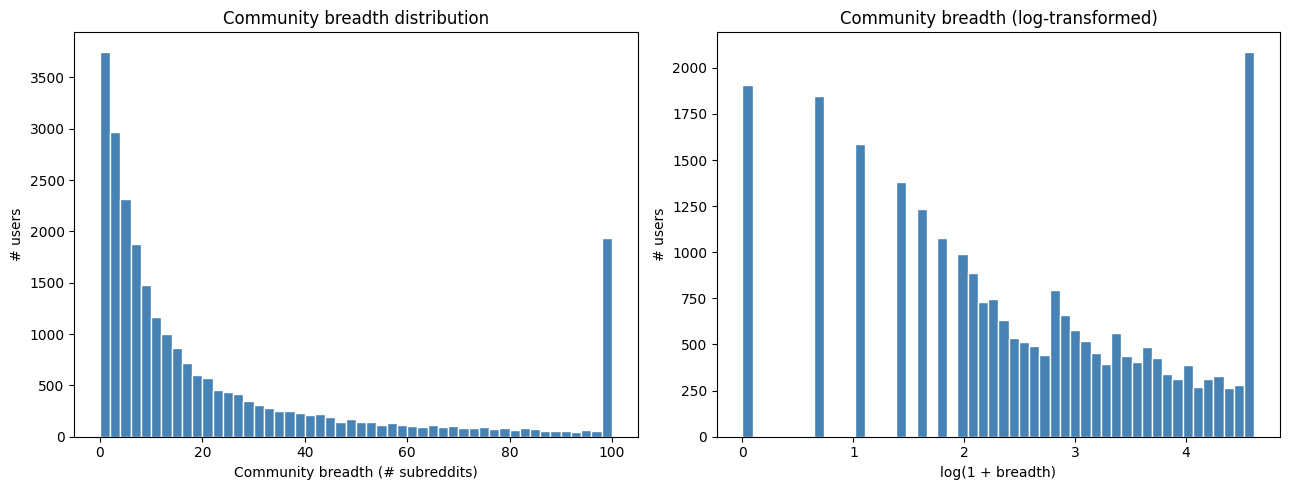

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(ok['community_breadth'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Community breadth (# subreddits)')
axes[0].set_ylabel('# users')
axes[0].set_title('Community breadth distribution')

axes[1].hist(ok['community_breadth_log'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log(1 + breadth)')
axes[1].set_ylabel('# users')
axes[1].set_title('Community breadth (log-transformed)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_community_breadth_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Community breadth by exposure status:


,count,mean,std,min,25%,50%,75%,max
exposed,,,,,,,,
False,24364.0,23.33,29.63,0.0,3.0,10.0,30.0,100.0
True,941.0,17.14,23.53,0.0,3.0,8.0,21.0,100.0


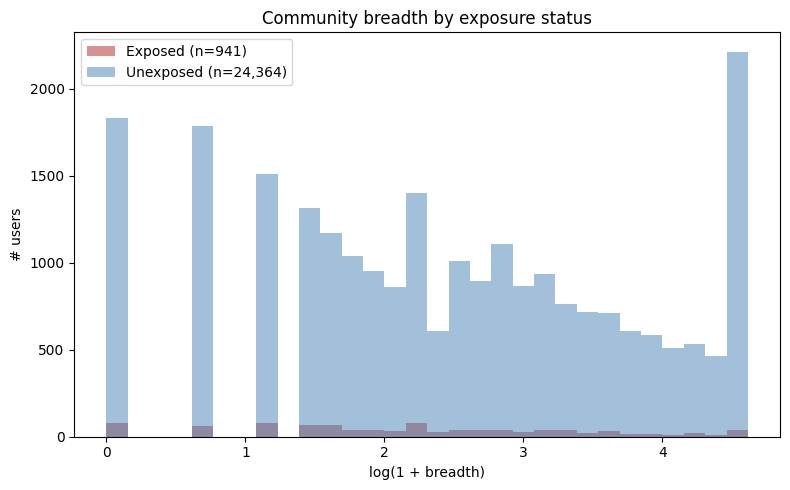

In [8]:
# Compare breadth: exposed vs unexposed users
exposure_df_clean = exposure_df.drop_duplicates('author')
merged = ok.merge(exposure_df_clean[['author', 'exposed']], on='author', how='left')

print('Community breadth by exposure status:')
display(merged.groupby('exposed')['community_breadth'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
for exp_val, label, color in [(True, 'Exposed', 'firebrick'), (False, 'Unexposed', 'steelblue')]:
    sub = merged[merged['exposed'] == exp_val]['community_breadth_log']
    ax.hist(sub, bins=30, alpha=0.5, label=f'{label} (n={len(sub):,})', color=color)
ax.set_xlabel('log(1 + breadth)')
ax.set_ylabel('# users')
ax.set_title('Community breadth by exposure status')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_breadth_by_exposure.png', dpi=150, bbox_inches='tight')
plt.show()